#  Multigrate — Paired CITE-seq Integration
### Based on: *Multigrate: single-cell multi-omic data integration* (Lotfollahi, Litinetskaya & Theis, ICML Workshop on Computational Biology, 2021)
**Repository:** [FaiqaZarar/multigrate-multiomics](https://github.com/FaiqaZarar/multigrate-multiomics)

This notebook reproduces the core paired CITE-seq integration experiment from the paper.  
Code adapted from the official reproducibility repository:  
https://github.com/theislab/multigrate_reproducibility

---
>  Estimated runtime: ~30 min on T4 GPU  
>  Set: **Runtime → Change runtime type → T4 GPU** before running

## Step 1 — Install packages
Run this cell, then **Runtime → Restart runtime**, then run all remaining cells.

In [1]:
!pip install -q git+https://github.com/theislab/multigrate.git
!pip install -q muon
print(" Done. Now: Runtime → Restart runtime → then Run all remaining cells")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
 Done. Now: Runtime → Restart runtime → then Run all remaining cells


## Step 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import scanpy as sc
import multigrate as mtg
import matplotlib.pyplot as plt
from matplotlib import rcParams

sc.set_figure_params(dpi=100, dpi_save=300, figsize=(6,5))
sc.settings.verbosity = 1

print("scanpy:", sc.__version__)
print("multigrate:", mtg.__version__)


scanpy: 1.11.5
multigrate: 0.1.0


## Step 3 — Download dataset
NeurIPS 2021 CITE-seq BMMCs from NCBI GEO (~500 MB).  
This is the exact dataset used in the paper.


In [3]:
fname = "GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad"

if not os.path.exists(fname):
    print("Downloading... (~2-3 min)")
    !wget -q 'ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz'
    !gzip -d GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz
    print("✅ Downloaded!")
else:
    print("✅ Already exists, skipping download.")

cite = sc.read(fname)
print(cite)


Downloading... (~2-3 min)
✅ Downloaded!
AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'


## Step 4 — Preprocess RNA and ADT
Exactly following the official preprocessing notebook:  
`multigrate_reproducibility/paired/pp/neurips2021_cite.ipynb`


In [4]:
# Subsample for Colab (official paper uses full 90k cells)
sc.pp.subsample(cite, n_obs=20000, random_state=0)
print(f"Subsampled to: {cite.n_obs} cells")

# ── Split RNA and ADT ──
rna = cite[:, cite.var['feature_types'] == 'GEX'].copy()
adt = cite[:, cite.var['feature_types'] == 'ADT'].copy()
print(f"RNA: {rna.n_obs} × {rna.n_vars}")
print(f"ADT: {adt.n_obs} × {adt.n_vars}")

# ── Preprocess RNA (official method) ──
rna.X = rna.layers['counts'].copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=4000, batch_key='batch')
rna_hvg = rna[:, rna.var.highly_variable].copy()
print(f"RNA after HVG selection: {rna_hvg.n_vars} genes")

# ── Preprocess ADT: CLR normalisation (official method) ──
def clr_normalize_each_cell(adata, inplace=True):
    """CLR normalisation — taken directly from official preprocessing notebook."""
    import numpy as np
    from scipy.sparse import issparse
    def seurat_clr(x):
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)
    if not inplace:
        adata = adata.copy()
    if issparse(adata.X):
        adata.X = np.apply_along_axis(seurat_clr, 1, adata.X.toarray())
    else:
        adata.X = np.apply_along_axis(seurat_clr, 1, adata.X)
    return adata

adt.X = adt.layers['counts'].copy()
adt = clr_normalize_each_cell(adt)
print("ADT CLR normalisation done.")


Subsampled to: 20000 cells
RNA: 20000 × 13953
ADT: 20000 × 134
RNA after HVG selection: 4000 genes
ADT CLR normalisation done.


## Step 5 — Combine modalities

In [6]:
# Combine modalities
adata = mtg.data.organize_multimodal_anndatas(
    adatas  = [[rna_hvg], [adt]],
    layers  = [['counts'], [None]],
)
print("Combined AnnData:")
print(adata)

Combined AnnData:
AnnData object with n_obs × n_vars = 20000 × 4134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'group'
    var: 'modality'
    uns: 'modality_lengths'
    layers: 'counts'


## Step 6 — Set up model

In [8]:
rna_indices_end = rna_hvg.n_vars  # = 4000

mtg.model.MultiVAE.setup_anndata(
    adata,
    categorical_covariate_keys=['batch'],
    rna_indices_end=rna_indices_end,
)

model = mtg.model.MultiVAE(
    adata,
    losses=['nb', 'mse'],
    loss_coefs={'kl': 1e-1, 'integ': 0},
)
print(model)

Training status: Not Trained

## Step 7 — Train (~15-20 min on GPU)

In [9]:
model.train(max_epochs=200, lr=1e-3, batch_size=256)
print("✅ Training complete!")


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


✅ Training complete!


## Step 8 — Extract latent space and plot UMAP

In [12]:
# Check what keys were stored
model.get_model_output(adata)
print("Available obsm keys:", list(adata.obsm.keys()))

Available obsm keys: ['_scvi_extra_categorical_covs', 'X_multigrate']


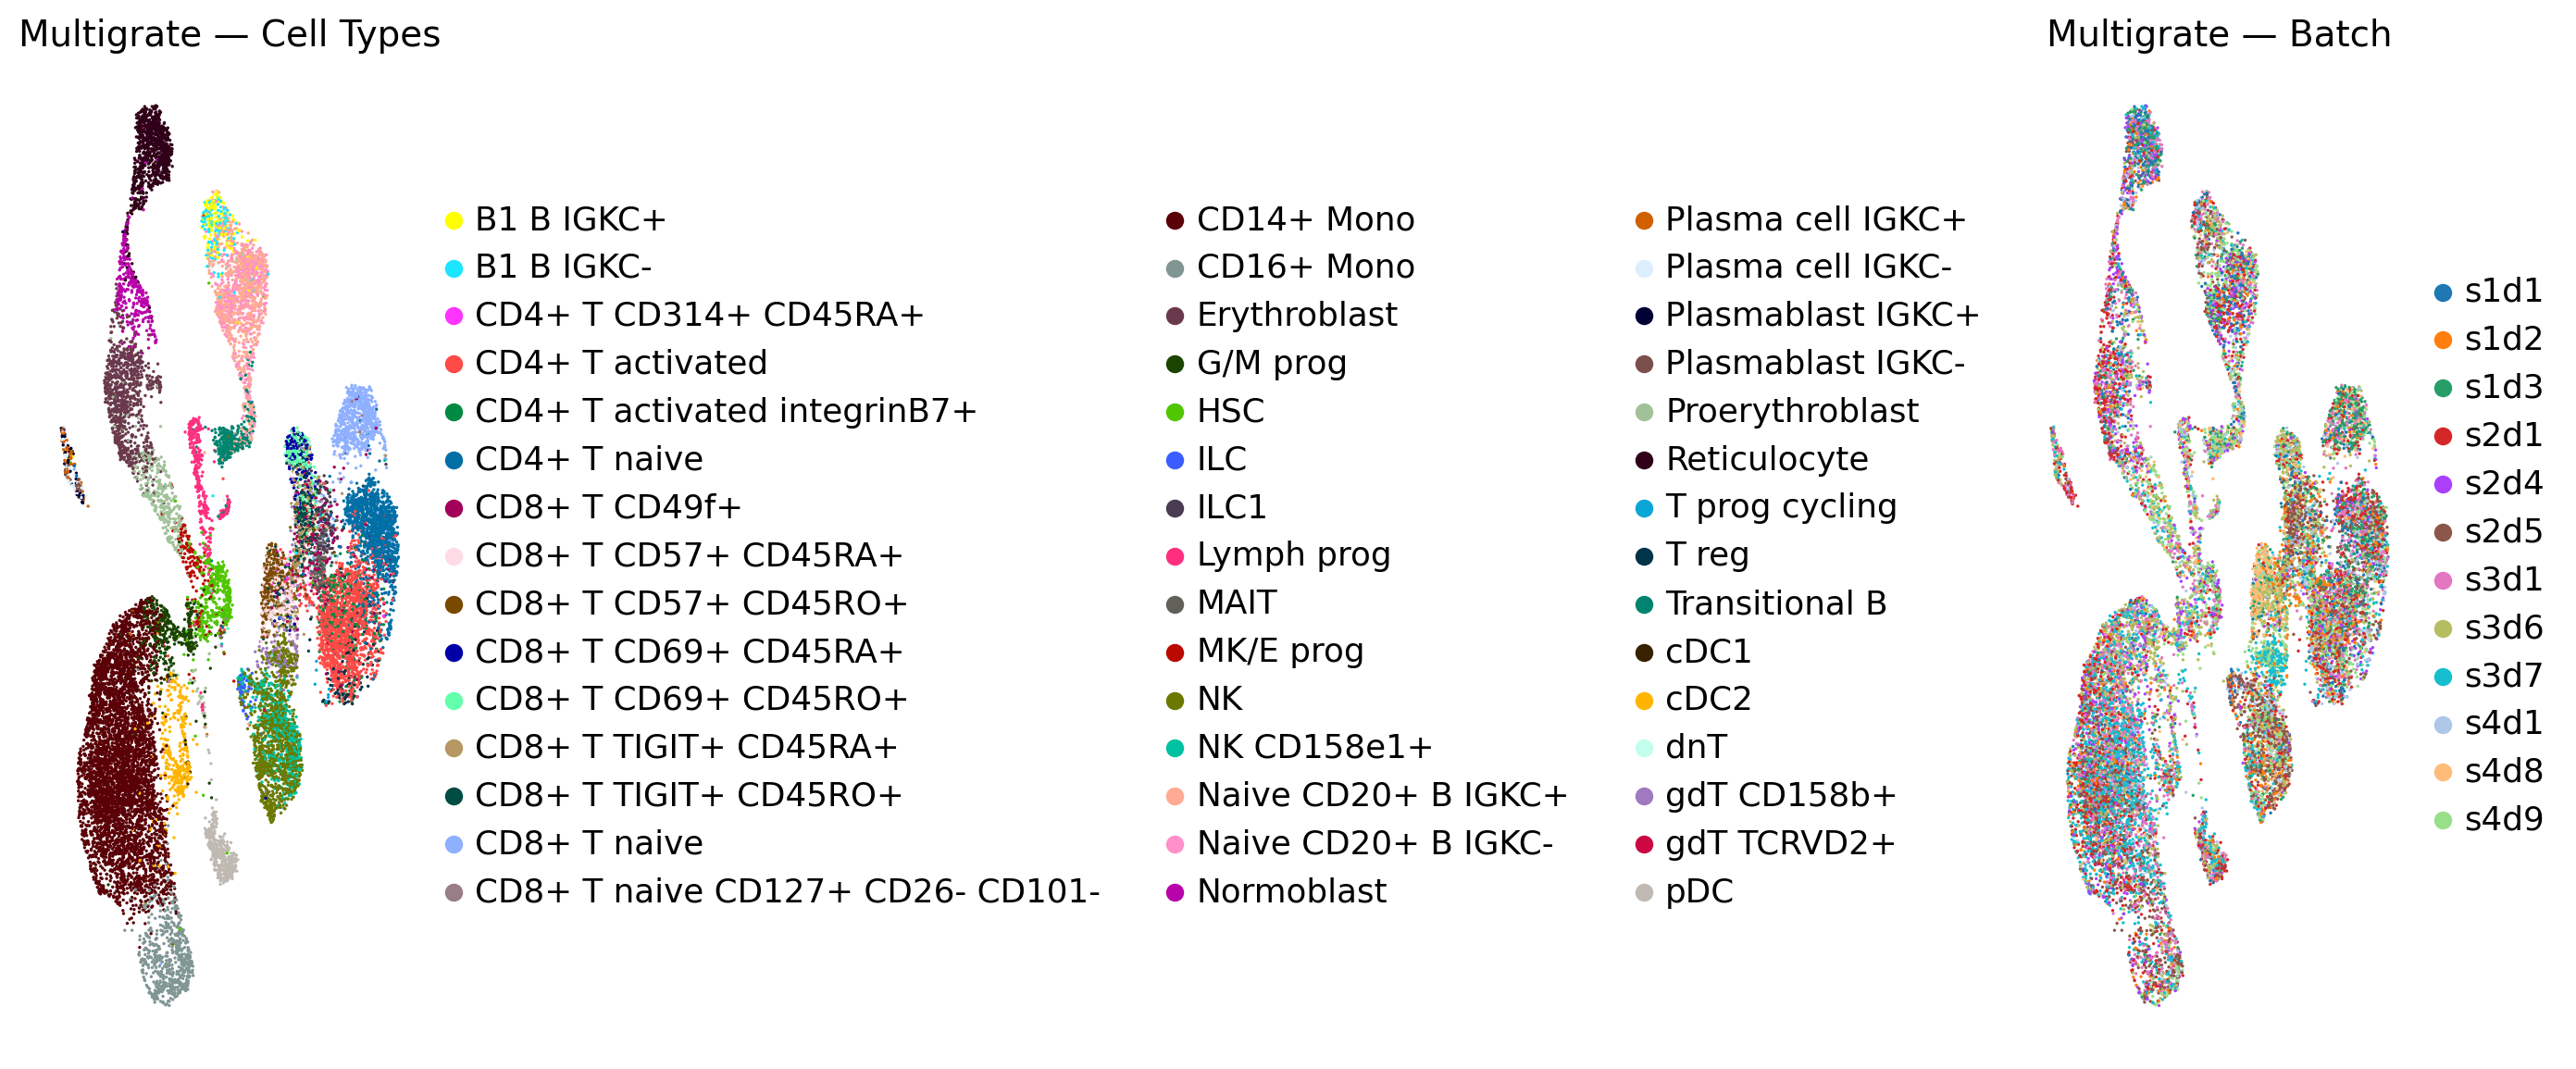

✅ Saved: figures/01_umap_celltype_batch.png


In [13]:
model.get_model_output(adata)

sc.pp.neighbors(adata, use_rep='X_multigrate')
sc.tl.umap(adata)

os.makedirs("figures", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.umap(adata, color='cell_type', frameon=False,
           title='Multigrate — Cell Types', ax=axes[0], show=False)
sc.pl.umap(adata, color='batch', frameon=False,
           title='Multigrate — Batch', ax=axes[1], show=False)
plt.tight_layout()
plt.savefig("figures/01_umap_celltype_batch.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/01_umap_celltype_batch.png")

## Step 9 — Training loss curves

In [15]:
print(model.history.keys())

dict_keys(['kl_weight', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'integ_loss_validation', 'modality_0_reconstruction_loss_validation', 'modality_1_reconstruction_loss_validation', 'train_loss', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'integ_loss_train', 'modality_0_reconstruction_loss_train', 'modality_1_reconstruction_loss_train'])


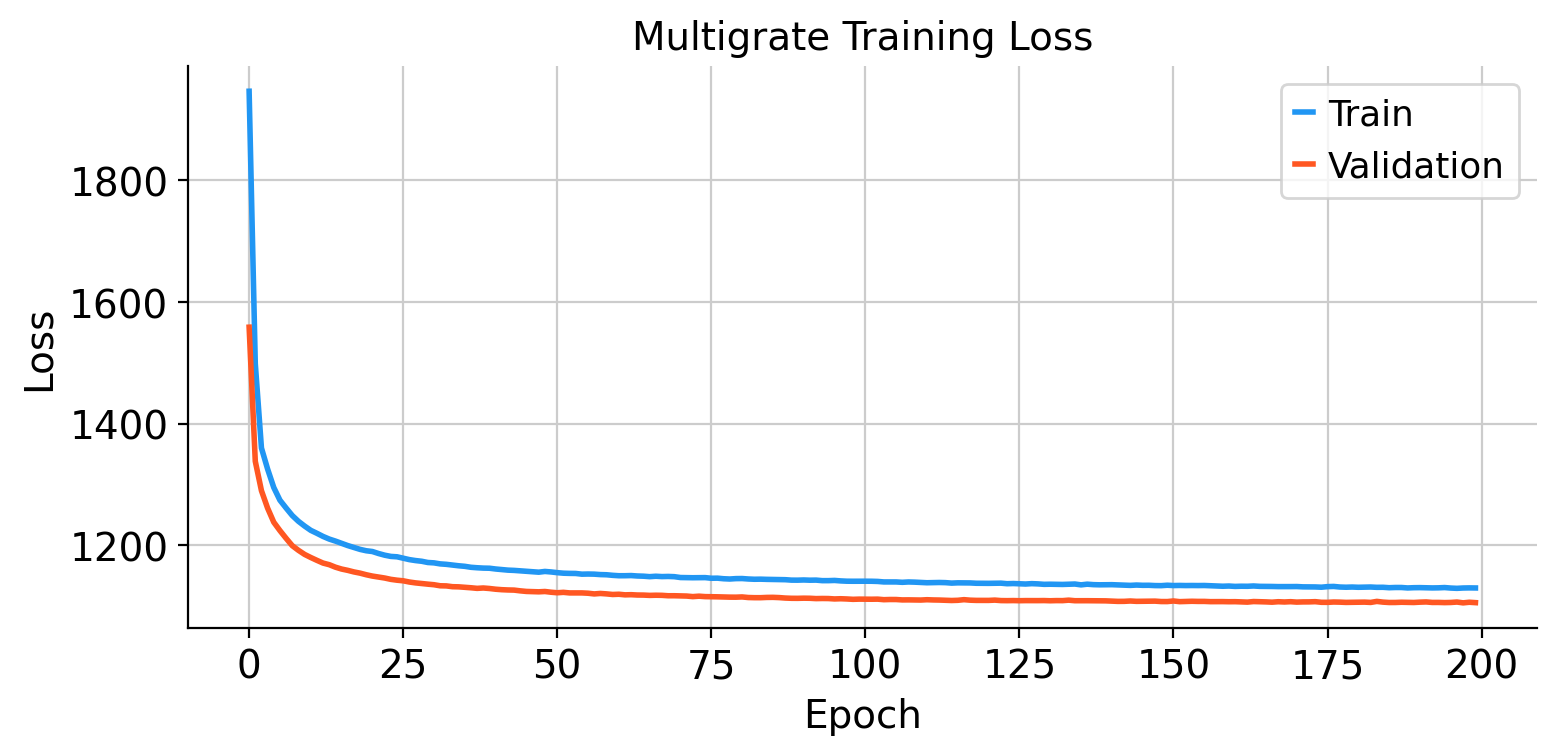

✅ Saved: figures/02_training_loss.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.history['train_loss'], color='#2196F3', linewidth=2, label='Train')
ax.plot(model.history['validation_loss'], color='#FF5722', linewidth=2, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Multigrate Training Loss')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/02_training_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/02_training_loss.png")

## Step 10 — Integration quality metrics

In [18]:
!pip install -q igraph leidenalg

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

le = LabelEncoder()
true_labels = le.fit_transform(adata.obs['cell_type'].values)
pred_labels = le.fit_transform(adata.obs['leiden'].values)

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)

print("=" * 40)
print("  Integration Quality Metrics")
print("=" * 40)
print(f"  ARI : {ari:.4f}  {'✅ good' if ari > 0.5 else '⚠️ low'}")
print(f"  NMI : {nmi:.4f}  {'✅ good' if nmi > 0.5 else '⚠️ low'}")
print("=" * 40)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.9 MB/s eta 0:00:00
  Integration Quality Metrics
  ARI : 0.6546  ✅ good
  NMI : 0.7739  ✅ good


## Step 11 — Download figures

In [19]:
import os
figs = os.listdir("figures")
print("Figures ready to download:")
for f in sorted(figs):
    size = os.path.getsize(f"figures/{f}") // 1024
    print(f"  📊 figures/{f}  ({size} KB)")

print()
print("To download: click the 📁 folder icon on the left sidebar")
print("→ open the 'figures' folder → right-click each file → Download")
print()
print("Then put them in: multigrate-multiomics/01_paired_integration/figures/")
print("And push to GitHub:")
print("  git add .")
print("  git commit -m 'Add Experiment 1 figures'")
print("  git push")


Figures ready to download:
  📊 figures/01_umap_celltype_batch.png  (599 KB)
  📊 figures/02_training_loss.png  (47 KB)

To download: click the 📁 folder icon on the left sidebar
→ open the 'figures' folder → right-click each file → Download

Then put them in: multigrate-multiomics/01_paired_integration/figures/
And push to GitHub:
  git add .
  git commit -m 'Add Experiment 1 figures'
  git push


---
## ✅ Summary

| Step | What happened |
|------|--------------|
| 1 | Installed multigrate from PyPI |
| 2 | Imported all libraries |
| 3 | Downloaded NeurIPS 2021 CITE-seq dataset |
| 4 | Preprocessed RNA (norm→log→HVG) and ADT (CLR) |
| 5 | Combined modalities using official API |
| 6 | Set up MultiVAE model |
| 7 | Trained for 200 epochs |
| 8 | Extracted latent space, computed UMAP |
| 9 | Plotted training loss |
| 10 | Measured ARI + NMI |

**Next:** Open `02_protein_imputation/protein_imputation.ipynb`

---
*Based on: https://github.com/theislab/multigrate_reproducibility*
